## power plots

Processing res/size_gaussian_p200_kappa_1.csv for plot: $(p,n) = (200,200)$, case $\mathrm{I}$
Processing res/size_gaussian_p400_kappa_1.csv for plot: $(p,n) = (400,400)$, case $\mathrm{I}$
Processing res/size_cauchy_p200_kappa_1.csv for plot: $(p,n) = (200,200)$, case $\mathrm{II}$
Processing res/size_cauchy_p400_kappa_1.csv for plot: $(p,n) = (400,400)$, case $\mathrm{II}$
Processing res/size_mix_p200_kappa_1.csv for plot: $(p,n) = (200,200)$, case $\mathrm{III}$
Processing res/size_mix_p400_kappa_1.csv for plot: $(p,n) = (400,400)$, case $\mathrm{III}$

Plots saved to res/qq_plots.pdf


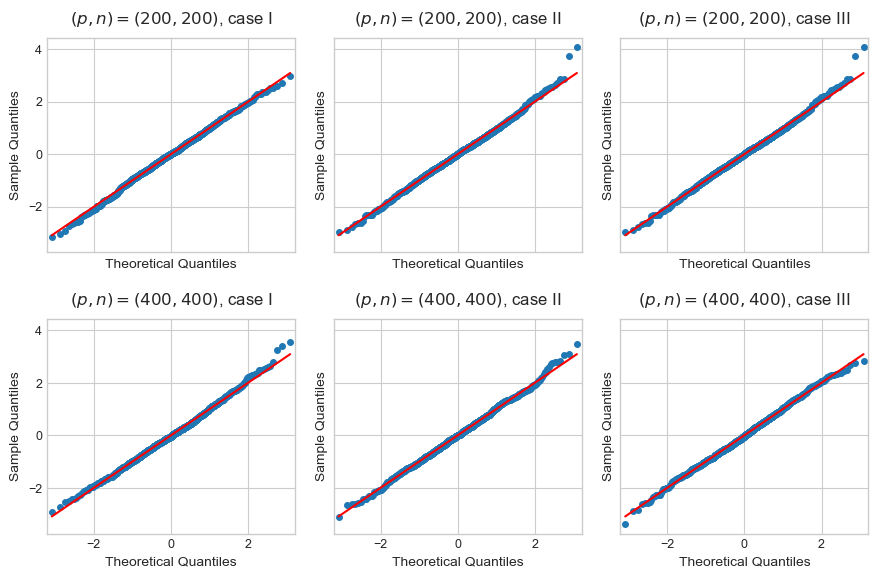

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import re # For extracting p-value more robustly
import os # For creating directories

# Optional: ensures plots are displayed inline in Jupyter
%matplotlib inline

file_paths = [
        'res/size_gaussian_p200_kappa_1.csv',
        'res/size_gaussian_p400_kappa_1.csv',
        'res/size_cauchy_p200_kappa_1.csv',
        'res/size_cauchy_p400_kappa_1.csv',
        'res/size_mix_p200_kappa_1.csv',
        'res/size_mix_p400_kappa_1.csv'
    ]

# LaTeX formatted custom titles
custom_titles = [
    r'$(p,n) = (200,200)$, case $\mathrm{I}$',
    r'$(p,n) = (400,400)$, case $\mathrm{I}$',
    r'$(p,n) = (200,200)$, case $\mathrm{II}$',
    r'$(p,n) = (400,400)$, case $\mathrm{II}$',
    r'$(p,n) = (200,200)$, case $\mathrm{III}$',
    r'$(p,n) = (400,400)$, case $\mathrm{III}$'
]

# Assumption for tau - MODIFY IF YOURS IS DIFFERENT
tau = 1.0

# Styling and font sizes
plt.style.use('seaborn-v0_8-whitegrid')
title_fontsize = 12
label_fontsize = 10
tick_fontsize = 9
title_pad_value = 10 # Padding for subplot titles

num_files = len(file_paths)
num_rows = 2
num_cols = 3

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols,
                         figsize=(9, 6),
                         sharex=True, sharey=True)

# Ensure axes is always a 2D array for consistent indexing
if num_rows == 1 and num_cols == 1:
    axes = np.array([[axes]])
elif num_rows == 1:
    axes = np.array([axes])
elif num_cols == 1:
    axes = np.array([[ax] for ax in axes])


for i, filepath in enumerate(file_paths):
    # Determine plot position (filling column by column)
    plot_col = i // num_rows
    plot_row = i % num_rows

    current_ax = axes[plot_row, plot_col]

    filename_base = filepath.split('/')[-1]
    title = custom_titles[i]

    # Extract p_val - this will error if the pattern is not found in the filename
    match_p = re.search(r'_p(\d+)_', filename_base)
    p_val = int(match_p.group(1))

    res_df = pd.read_csv(filepath)
    print(f"Processing {filepath} for plot: {title}")

    # Assuming p_val will be > 0 and required columns ['omega_n', 'betahat_1', 'w_hat_1', 'v_n'] exist
    # and Z_test_1 will not be empty.

    numerator = (tau + res_df['omega_n']) * res_df['betahat_1'] - tau * res_df['w_hat_1']
    denominator = res_df['v_n'] / np.sqrt(p_val) # np.sqrt will handle p_val > 0 check implicitly (NaN or error for p_val <=0)

    # Handle potential division by zero by replacing with NaN before division.
    # This is more of a data processing step than error handling for unexpected structure.
    denominator = denominator.replace(0, np.nan)

    Z_test_1 = (numerator / denominator).dropna() # Remove NaNs resulting from division or from original data

    sm.qqplot(Z_test_1, line='s', ax=current_ax, fit=True,
          marker='o', markersize=4)
    current_ax.set_title(title, fontsize=title_fontsize, pad=title_pad_value)

    # Axis labels only on outer plots due to sharex/sharey
    if plot_row == num_rows - 1: # Last row
        current_ax.set_xlabel(r'Theoretical Quantiles', fontsize=label_fontsize)
    if plot_col == 0: # First column
        current_ax.set_ylabel(r'Sample Quantiles', fontsize=label_fontsize)

    current_ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

plt.tight_layout(pad=1.5)

# Ensure output directory exists
output_dir = "res"
os.makedirs(output_dir, exist_ok=True)
output_filename = os.path.join(output_dir, "qq_plots.pdf")

plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"\nPlots saved to {output_filename}")
plt.show()

## boxplots

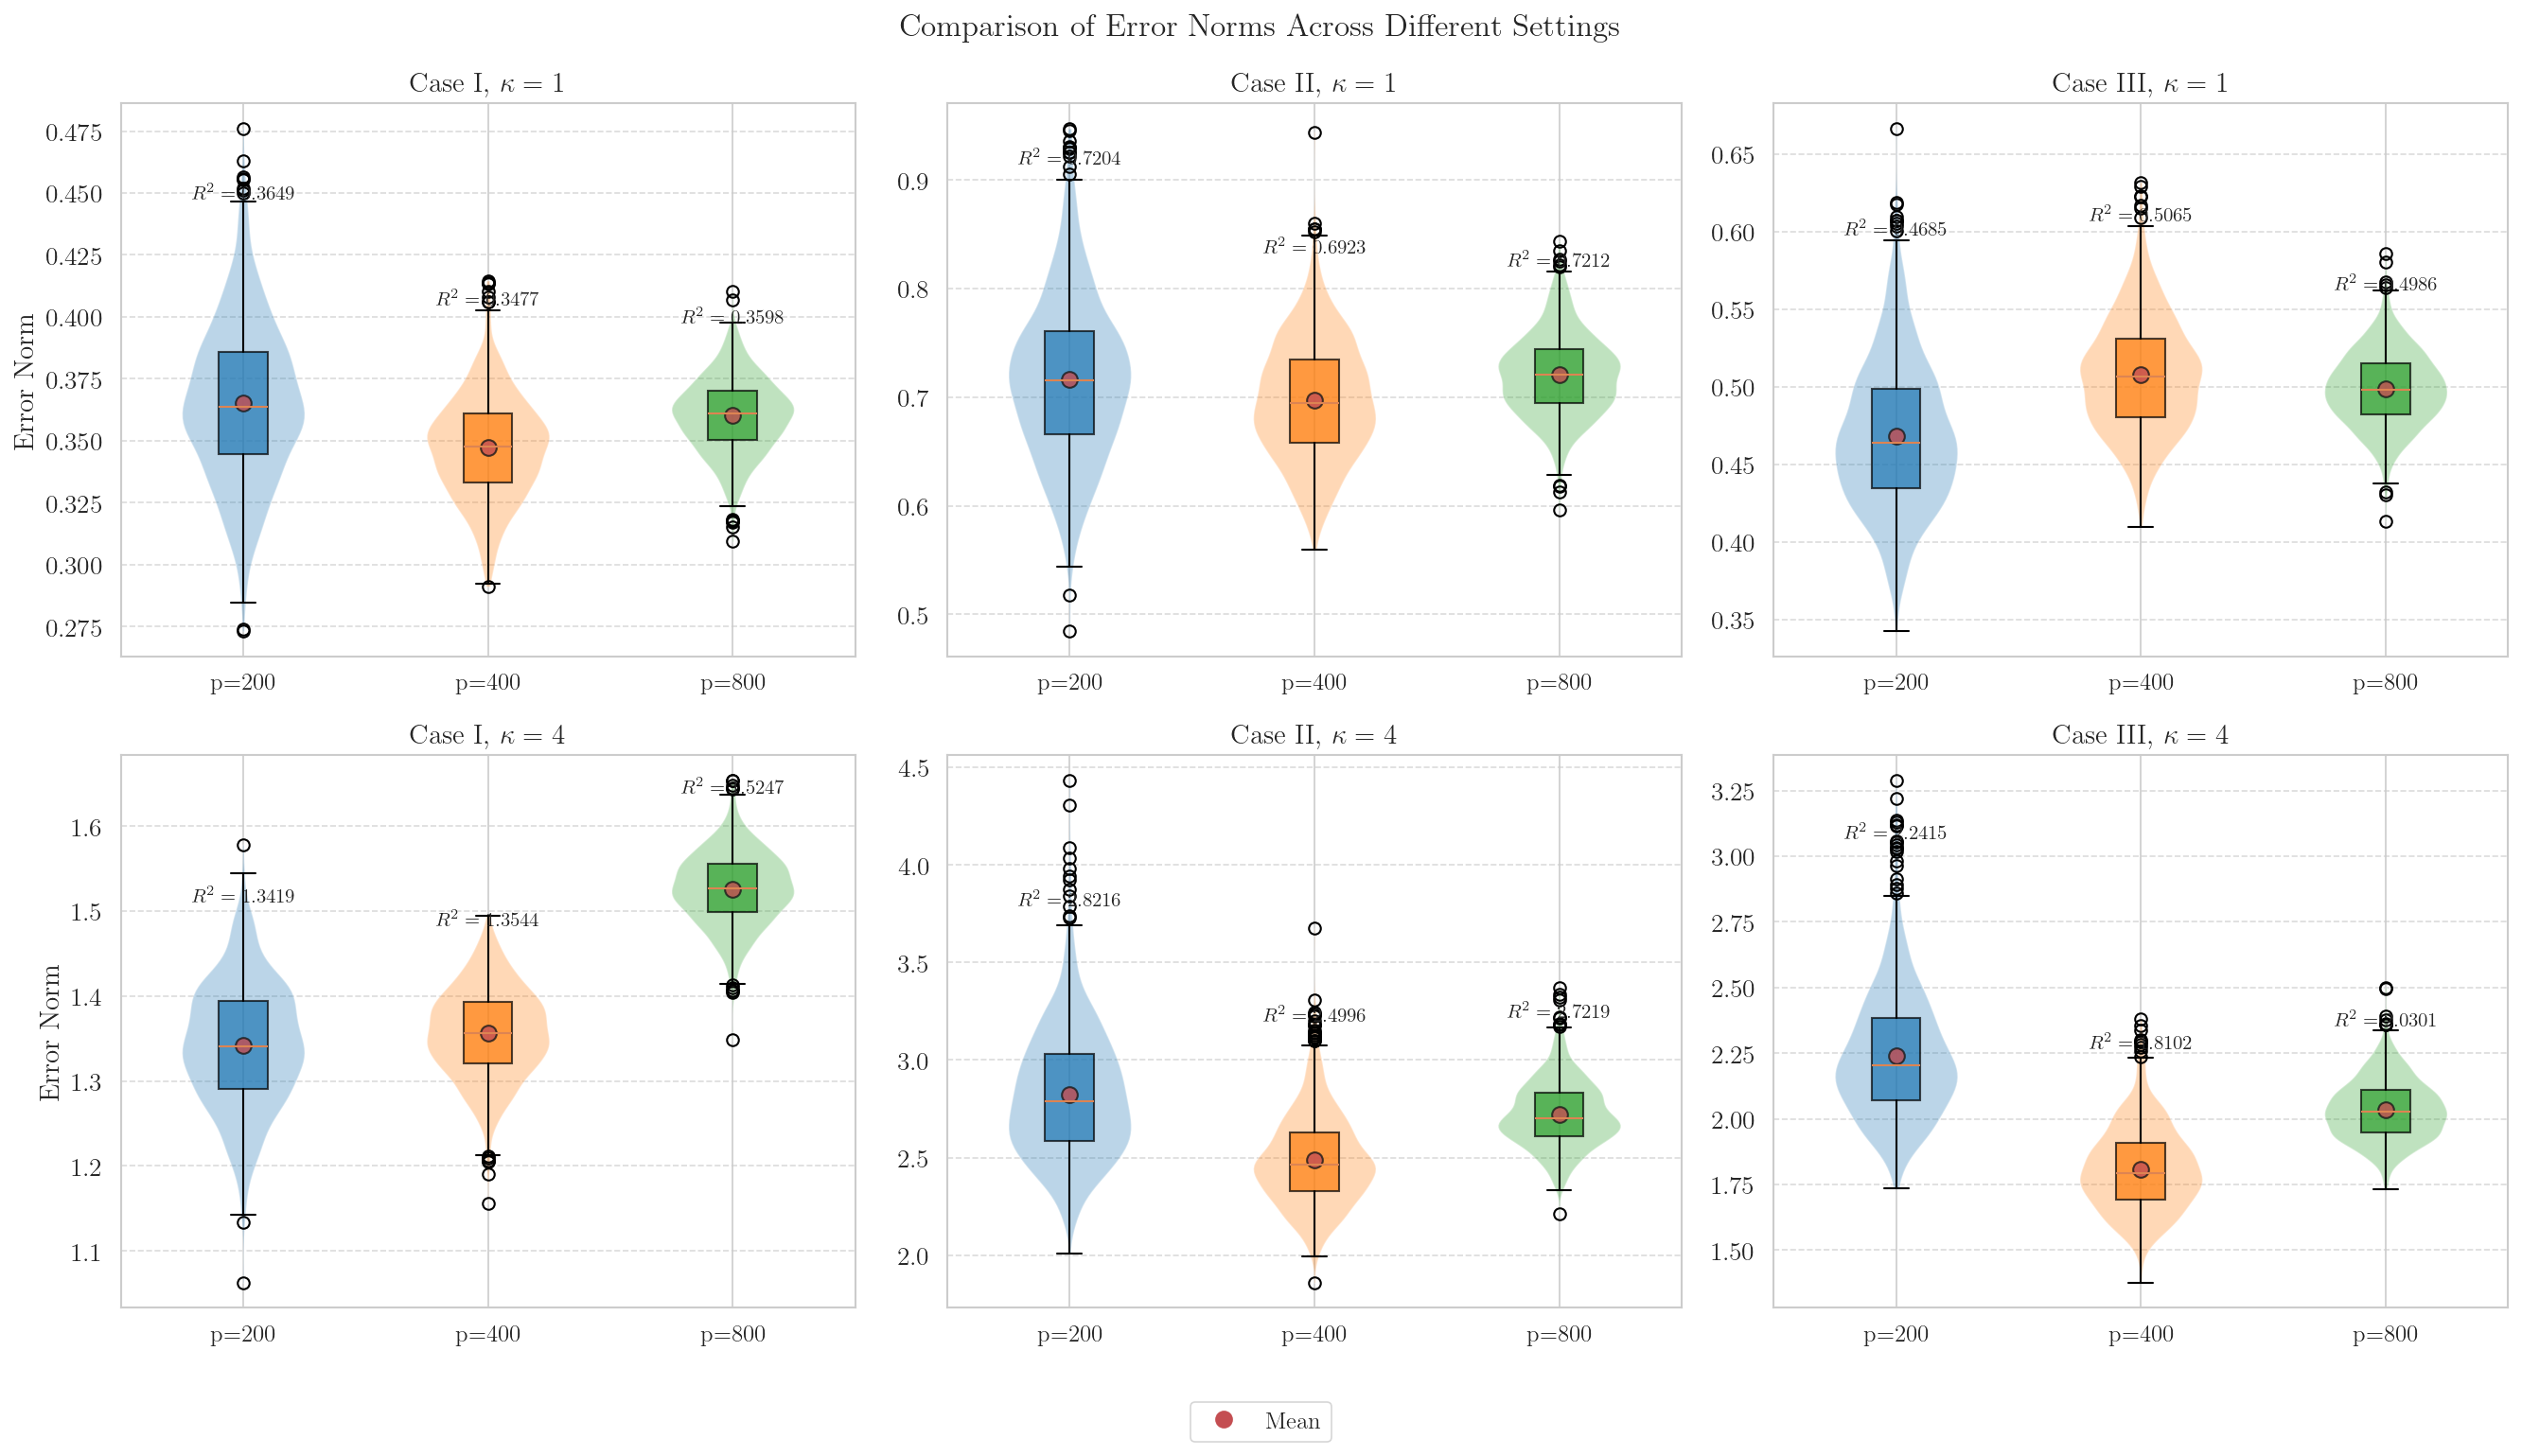

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# Set the style for publication-quality plots
# plt.style.use('seaborn-whitegrid')
sns.set_context("paper", font_scale=1.5)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'

# Define constants
K = 1000  # Number of simulations
p_values = [200, 400, 800]  # Different p values
kappa_values = [1, 4]  # Different kappa values
case_types = ["gaussian", "cauchy", "mix"]  # Different case types (I, II, III)
case_names = {"gaussian": "Case I", "cauchy": "Case II", "mix": "Case III"}

# Create a directory to save the plots
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True)

def load_data(kappa, case_type):
    """Load data from CSV files for a specific kappa value and case type."""
    csv_filename = f'res/res_kappa{kappa}_{case_type}.csv'

    try:
        data = pd.read_csv(csv_filename)
        # Extract the first K columns (error norms) and the last column (r2)
        err_norms = data.iloc[:, :K].values
        r2_values = data.iloc[:, K+1].values

        return err_norms, r2_values
    except FileNotFoundError:
        print(f"File not found: {csv_filename}")
        return None, None

# Dictionary to store all data
all_data = {}

# Load all data
for kappa in kappa_values:
    for case_type in case_types:
        err_norms, r2_values = load_data(kappa, case_type)
        if err_norms is not None:
            all_data[(kappa, case_type)] = (err_norms, r2_values)

def create_enhanced_boxplot():
    """Create an enhanced boxplot with violin plots for publication."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for i, kappa in enumerate(kappa_values):
        for j, case_type in enumerate(case_types):
            if (kappa, case_type) not in all_data:
                continue

            err_norms, r2_values = all_data[(kappa, case_type)]

            # Prepare data for boxplot
            box_data = []
            labels = []
            r2_annotations = []

            for k, p in enumerate(p_values):
                if k < len(err_norms):
                    box_data.append(err_norms[k, :K])
                    labels.append(f'p={p}')
                    r2_annotations.append(f'$R^2={r2_values[k]:.4f}$')

            # Create subplot
            ax = axes[i, j]

            # Create violin plots with boxplots inside
            positions = np.arange(1, len(box_data) + 1)
            violin_parts = ax.violinplot(box_data, positions=positions, showmedians=False, showextrema=False)

            # Customize violin colors
            colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
            for k, pc in enumerate(violin_parts['bodies']):
                pc.set_facecolor(colors[k % len(colors)])
                pc.set_alpha(0.3)

            # Add boxplots on top of violin plots
            box = ax.boxplot(box_data, patch_artist=True, widths=0.2)

            # Customize boxplot colors
            for k, patch in enumerate(box['boxes']):
                patch.set_facecolor(colors[k % len(colors)])
                patch.set_alpha(0.7)

            # Add R² annotations
            for k, r2_text in enumerate(r2_annotations):
                y_pos = np.percentile(box_data[k], 99)  # Position at 99th percentile
                ax.annotate(r2_text, xy=(k+1, y_pos), xytext=(0, 5),
                           textcoords='offset points', ha='center', fontsize=10)

            # Customize plot
            ax.set_xticklabels(labels, fontsize=12)
            if j == 0:
                ax.set_ylabel('Error Norm', fontsize=14)
            ax.set_title(f'{case_names[case_type]}, $\\kappa={kappa}$', fontsize=14)

            # Add grid lines
            ax.yaxis.grid(True, linestyle='--', alpha=0.7)

            # Add mean markers
            for k, data in enumerate(box_data):
                mean_val = np.mean(data)
                ax.plot(k+1, mean_val, 'ro', ms=8, mec='k', mew=1, alpha=0.8)

    # Add a common legend
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], marker='o', color='r', markerfacecolor='r',
                          markersize=8, linestyle='None', label='Mean')]
    fig.legend(handles=custom_lines, loc='upper center', bbox_to_anchor=(0.5, 0.02),
              ncol=3, frameon=True, fontsize=12)

    # Adjust layout
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])

    # Add a super title
    fig.suptitle('Comparison of Error Norms Across Different Settings', fontsize=16, y=0.99)

    # Save figure
    plt.savefig(output_dir / 'enhanced_boxplots.pdf', bbox_inches='tight', dpi=300)
    plt.savefig(output_dir / 'enhanced_boxplots.png', bbox_inches='tight', dpi=300)

    return fig

# Create enhanced figure
enhanced_fig = create_enhanced_boxplot()
plt.show()

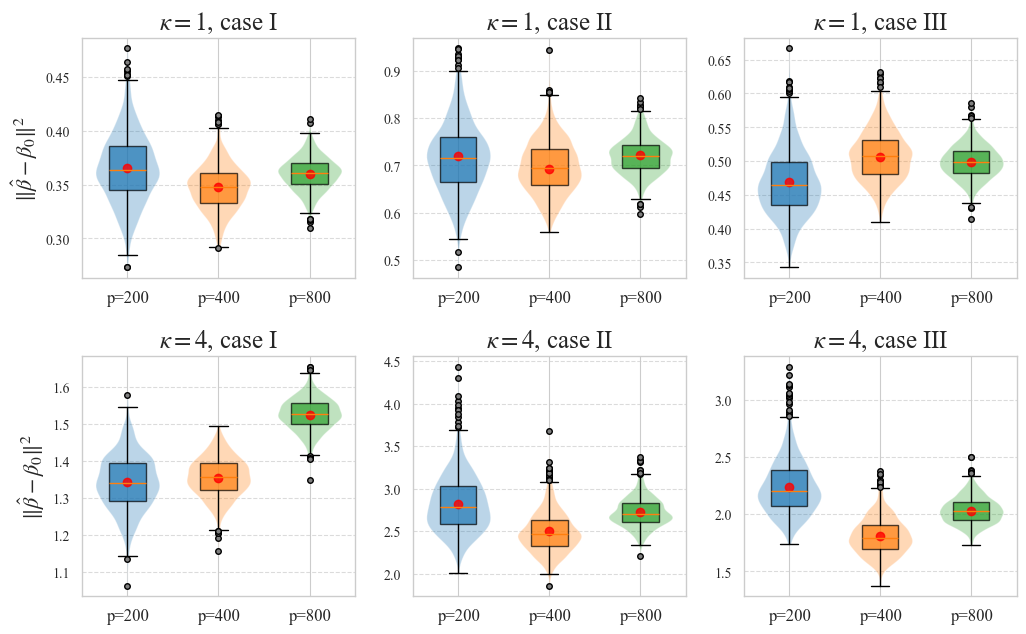

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# Set the style for publication-quality plots
# Use the updated style name for newer seaborn versions
try:
    plt.style.use('seaborn-whitegrid')  # For older versions
except:
    plt.style.use('seaborn-v0_8-whitegrid')  # For newer versions

sns.set_context("paper", font_scale=1.5)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'

# Define constants
K = 1000  # Number of simulations
p_values = [200, 400, 800]  # Different p values
kappa_values = [1, 4]  # Different kappa values
case_types = ["gaussian", "cauchy", "mix"]  # Different case types (I, II, III)
case_names = {"gaussian": "case I", "cauchy": "case II", "mix": "case III"}

# Create a directory to save the plots
output_dir = Path("res")
output_dir.mkdir(exist_ok=True)

def load_data(kappa, case_type):
    """Load data from CSV files for a specific kappa value and case type."""
    csv_filename = f'res/res_kappa{kappa}_{case_type}.csv'

    try:
        data = pd.read_csv(csv_filename)
        # Extract the first K columns (error norms) and the last column (r2)
        err_norms = data.iloc[:, :K].values
        r2_values = data.iloc[:, K+1].values

        return err_norms, r2_values
    except FileNotFoundError:
        print(f"File not found: {csv_filename}")
        return None, None

# Dictionary to store all data
all_data = {}

# Load all data
for kappa in kappa_values:
    for case_type in case_types:
        err_norms, r2_values = load_data(kappa, case_type)
        if err_norms is not None:
            all_data[(kappa, case_type)] = (err_norms, r2_values)

def create_enhanced_boxplot():
    """Create an enhanced boxplot with violin plots for publication."""
    fig, axes = plt.subplots(2, 3, figsize=(10.5, 7))

    for i, kappa in enumerate(kappa_values):
        for j, case_type in enumerate(case_types):
            if (kappa, case_type) not in all_data:
                continue

            err_norms, r2_values = all_data[(kappa, case_type)]

            # Prepare data for boxplot
            box_data = []
            labels = []

            for k, p in enumerate(p_values):
                if k < len(err_norms):
                    box_data.append(err_norms[k, :K])
                    labels.append(f'p={p}')

            # Create subplot
            ax = axes[i, j]

            # Create violin plots with boxplots inside
            positions = np.arange(1, len(box_data) + 1)
            violin_parts = ax.violinplot(box_data, positions=positions, showmedians=False, showextrema=False, widths=0.7)

            # Customize violin colors
            colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
            for k, pc in enumerate(violin_parts['bodies']):
                pc.set_facecolor(colors[k % len(colors)])
                pc.set_alpha(0.3)

            # Define flierprops to control outlier appearance
            flierprops = dict(marker='o', markerfacecolor='grey', markersize=4,
                             linestyle='none', markeredgecolor='black')

            # Add boxplots on top of violin plots with custom outlier size
            box = ax.boxplot(box_data, patch_artist=True, widths=0.4, flierprops=flierprops)


            # Customize boxplot colors
            for k, patch in enumerate(box['boxes']):
                patch.set_facecolor(colors[k % len(colors)])
                patch.set_alpha(0.7)

            # Customize plot
            ax.set_xticklabels(labels, fontsize=12)
            # Set y-axis tick label size
            ax.tick_params(axis='y', labelsize=10)
            if j == 0:
                # Set y-axis label to the mathematical expression
                ax.set_ylabel(r'$\|\hat{\beta}-\beta_0\|^2$', fontsize=16)
            ax.set_title(f'$\\kappa={kappa}$, {case_names[case_type]}', fontsize=18)

            # Add grid lines
            ax.yaxis.grid(True, linestyle='--', alpha=0.7)

            # Add R² values as points instead of mean
            for k in range(len(box_data)):
                if k < len(r2_values):
                    # Plot R² value as a blue point
                    ax.plot(k+1, r2_values[k], 'ro', ms=6, alpha=0.8)

    # Add a common legend
    # from matplotlib.lines import Line2D
    # custom_lines = [Line2D([0], [0], marker='o', color='r', markerfacecolor='r',
    #                       markersize=8, linestyle='None', label='Mean')]
    # fig.legend(handles=custom_lines, loc='upper center', bbox_to_anchor=(0.5, 0.02),
    #           ncol=3, frameon=True, fontsize=12)

    # Adjust layout
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])

    # Save figure
    plt.savefig(output_dir / 'boxplots.pdf', bbox_inches='tight', dpi=300)

    return fig

# Create enhanced figure
enhanced_fig = create_enhanced_boxplot()
plt.show()